In [1]:
import sys
print(sys.version)

3.14.5 (tags/v3.14.5:5607950, May 10 2026, 10:43:50) [MSC v.1944 64 bit (AMD64)]


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For better visualization
sns.set(style="whitegrid")

Load Dataset

In [ ]:
import pandas as pd
file_path = r'C:\Users\rbhat\Downloads\Kids_Screen_Time.csv'
df = pd.read_csv(file_path)
print(df.head())

   Age  Gender  Avg_Daily_Screen_Time_hr Primary_Device  \
0   14    Male                      3.99     Smartphone   
1   11  Female                      4.61         Laptop   
2   18  Female                      3.73             TV   
3   15  Female                      1.21         Laptop   
4   12  Female                      5.89     Smartphone   

   Exceeded_Recommended_Limit  Educational_to_Recreational_Ratio  \
0                        True                               0.42   
1                        True                               0.30   
2                        True                               0.32   
3                       False                               0.39   
4                        True                               0.49   

           Health_Impacts Urban_or_Rural  
0  Poor Sleep, Eye Strain          Urban  
1              Poor Sleep          Urban  
2              Poor Sleep          Urban  
3                     NaN          Urban  
4     Poor Sleep, Anx

Basic Exploration

In [6]:
print("First 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())

First 5 rows:
   Age  Gender  Avg_Daily_Screen_Time_hr Primary_Device  \
0   14    Male                      3.99     Smartphone   
1   11  Female                      4.61         Laptop   
2   18  Female                      3.73             TV   
3   15  Female                      1.21         Laptop   
4   12  Female                      5.89     Smartphone   

   Exceeded_Recommended_Limit  Educational_to_Recreational_Ratio  \
0                        True                               0.42   
1                        True                               0.30   
2                        True                               0.32   
3                       False                               0.39   
4                        True                               0.49   

           Health_Impacts Urban_or_Rural  
0  Poor Sleep, Eye Strain          Urban  
1              Poor Sleep          Urban  
2              Poor Sleep          Urban  
3                     NaN          Urban  
4     P

Data Cleaning

In [7]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert boolean column if needed
df['Exceeded_Recommended_Limit'] = df['Exceeded_Recommended_Limit'].astype(bool)

Univariate Analysis

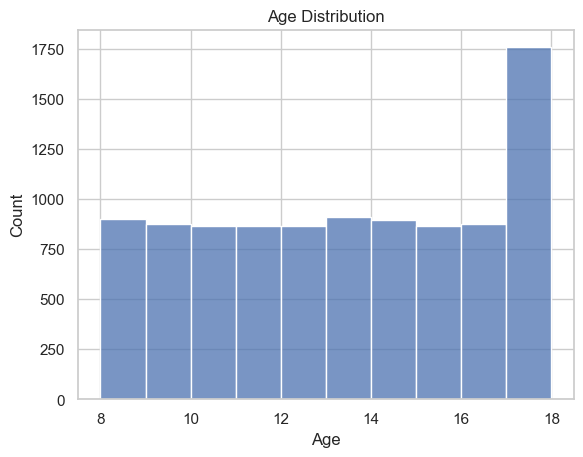

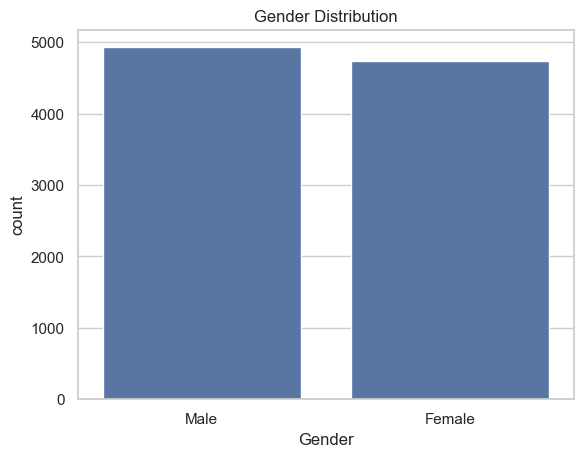

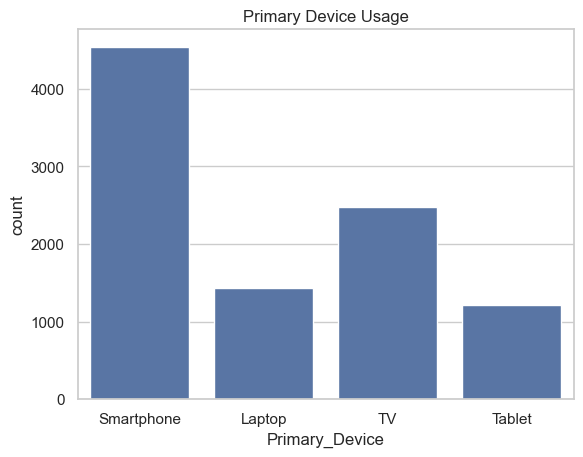

In [8]:
# Age distribution
plt.figure()
sns.histplot(df['Age'], bins=10)
plt.title("Age Distribution")
plt.show()

# Gender count
plt.figure()
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

# Device usage
plt.figure()
sns.countplot(x='Primary_Device', data=df)
plt.title("Primary Device Usage")
plt.show()

Bivariate Analysis

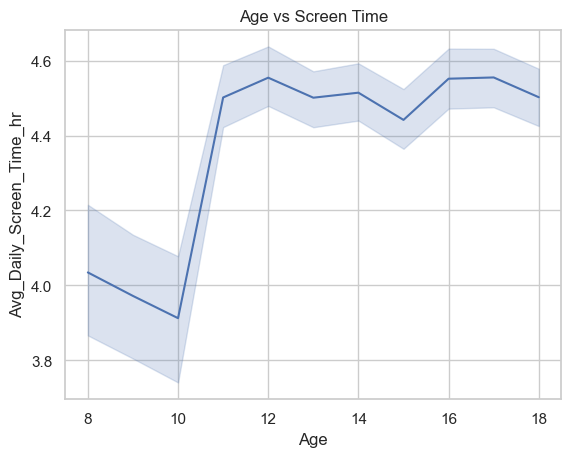

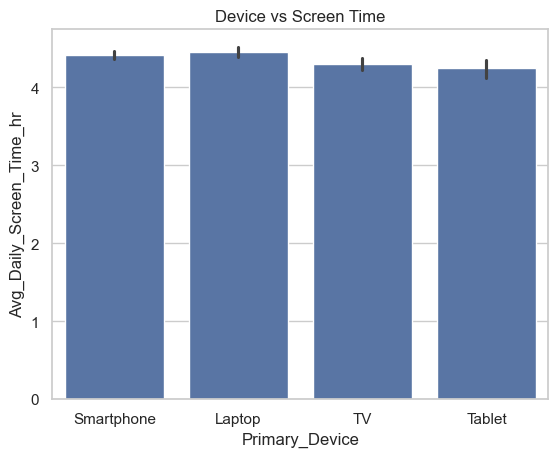

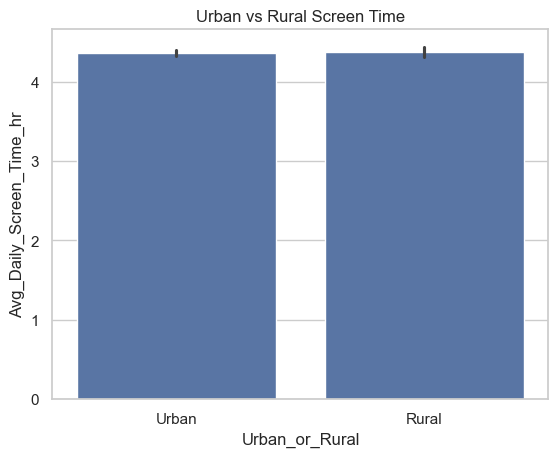

In [9]:
# Age vs Screen Time
plt.figure()
sns.lineplot(x='Age', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title("Age vs Screen Time")
plt.show()

# Device vs Screen Time
plt.figure()
sns.barplot(x='Primary_Device', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title("Device vs Screen Time")
plt.show()

# Urban vs Screen Time
plt.figure()
sns.barplot(x='Urban_or_Rural', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title("Urban vs Rural Screen Time")
plt.show()

Health Impact Analysis

In [11]:
print(df.columns.tolist())

['Age', 'Gender', 'Avg_Daily_Screen_Time_hr', 'Primary_Device', 'Exceeded_Recommended_Limit', 'Educational_to_Recreational_Ratio', 'Health_Impacts', 'Urban_or_Rural']


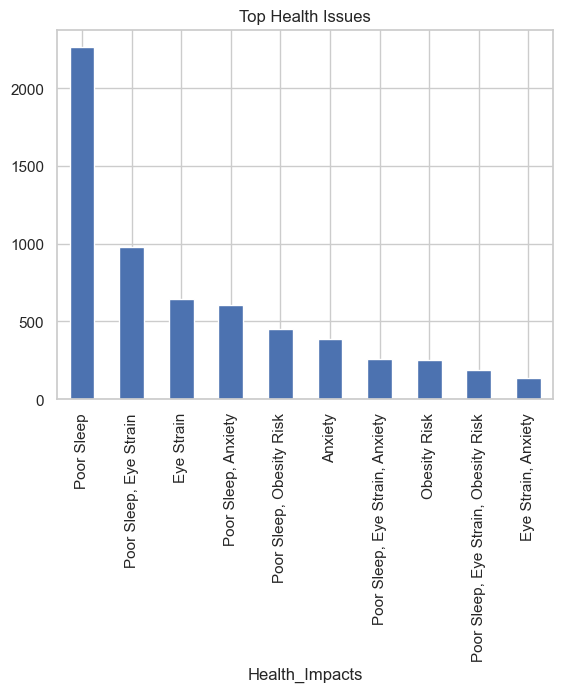

In [12]:
# Count most common health issues
health_counts = df['Health_Impacts'].value_counts()

plt.figure()
health_counts.head(10).plot(kind='bar')
plt.title("Top Health Issues")
plt.show()

Screen time Limit Analysis

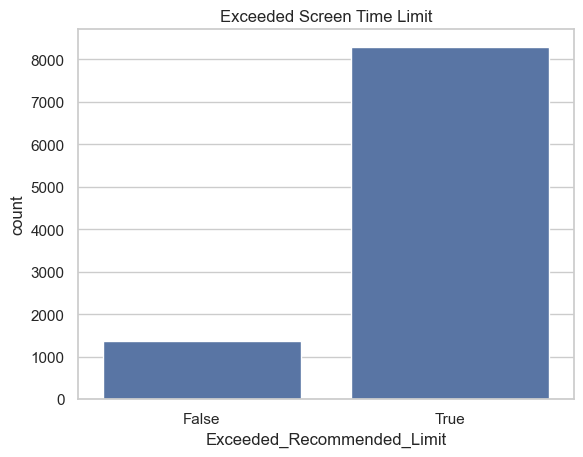

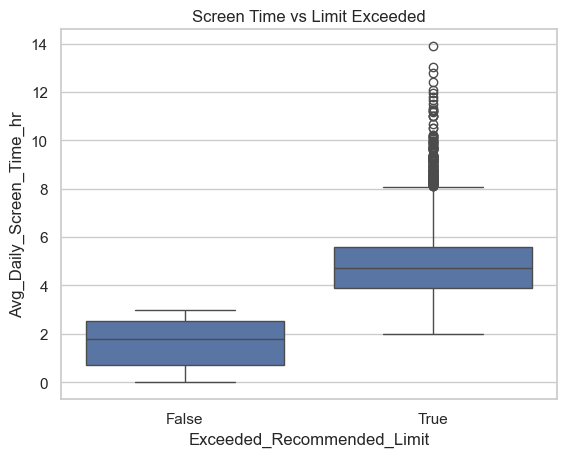

In [13]:
plt.figure()
sns.countplot(x='Exceeded_Recommended_Limit', data=df)
plt.title("Exceeded Screen Time Limit")
plt.show()

# Screen time vs exceeded limit
plt.figure()
sns.boxplot(x='Exceeded_Recommended_Limit', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title("Screen Time vs Limit Exceeded")
plt.show()

Correlation Analysis

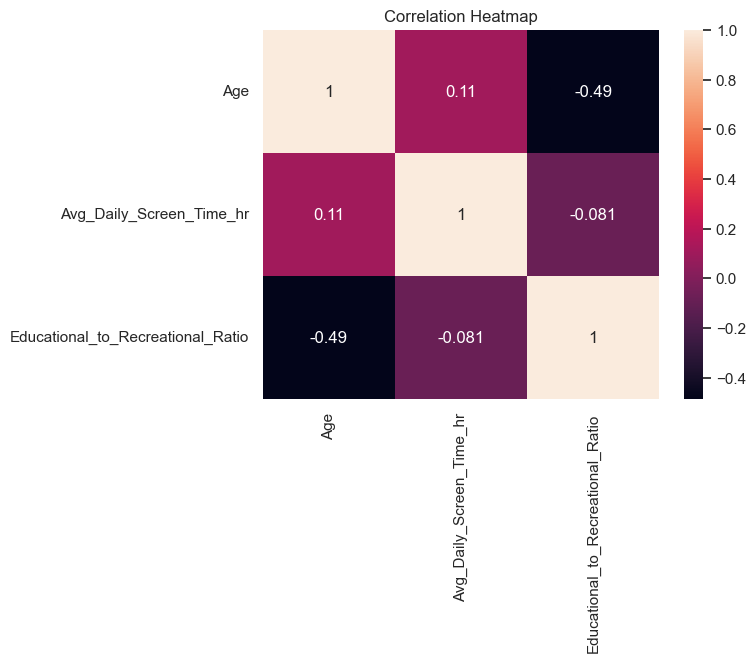

In [14]:
# Select numeric columns
numeric_df = df.select_dtypes(include=np.number)

plt.figure()
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

Feature Engineering

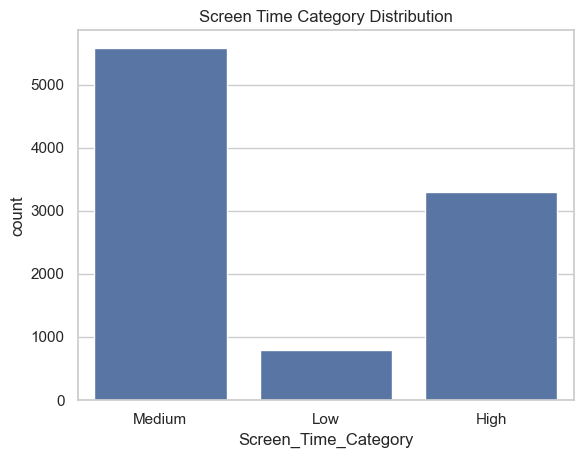

In [15]:
# Create Screen Time Category
def categorize_time(x):
    if x < 2:
        return "Low"
    elif x < 5:
        return "Medium"
    else:
        return "High"

df['Screen_Time_Category'] = df['Avg_Daily_Screen_Time_hr'].apply(categorize_time)

# Plot new feature
plt.figure()
sns.countplot(x='Screen_Time_Category', data=df)
plt.title("Screen Time Category Distribution")
plt.show()

Insights Print

In [16]:
print("\nAverage Screen Time by Device:")
print(df.groupby('Primary_Device')['Avg_Daily_Screen_Time_hr'].mean())

print("\nAverage Screen Time by Area:")
print(df.groupby('Urban_or_Rural')['Avg_Daily_Screen_Time_hr'].mean())

print("\nScreen Time vs Age:")
print(df.groupby('Age')['Avg_Daily_Screen_Time_hr'].mean())


Average Screen Time by Device:
Primary_Device
Laptop        4.458784
Smartphone    4.410154
TV            4.299544
Tablet        4.241846
Name: Avg_Daily_Screen_Time_hr, dtype: float64

Average Screen Time by Area:
Urban_or_Rural
Rural    4.375640
Urban    4.364482
Name: Avg_Daily_Screen_Time_hr, dtype: float64

Screen Time vs Age:
Age
8     4.034711
9     3.972046
10    3.912665
11    4.501541
12    4.554348
13    4.500967
14    4.514346
15    4.441725
16    4.551636
17    4.554989
18    4.502217
Name: Avg_Daily_Screen_Time_hr, dtype: float64
